# 03 — Engagement modeling (WER → BRI)

Predict **raw `weighted_engagement_rate`** from **pre-publish** features only.

- **Select on:** MAE (WER); RMSE / Spearman auxiliary
- **Models:** CatBoost vs XGBoost (same features)
- **CV:** `GroupKFold` by `author_id`
- **BRI:** `pred_BRI = pred_WER / median(WER | brand)` using **train-fold** brand medians

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if not (ROOT / "configs").exists() and (ROOT.parent / "configs").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tiktok_brand.analysis.data import load_feature_table, project_paths
from tiktok_brand.analysis.metrics import leakage_checklist
from tiktok_brand.analysis.modeling import (
    LEAKAGE_COLS,
    holdout_eval,
    prepare_model_frame,
    run_grouped_cv,
    summarize_cv,
    wer_to_bri,
)

PATHS = project_paths(ROOT / "configs" / "project.yaml")
df = load_feature_table(PATHS["feature_table"])
print(df.shape)
df.head(2)

## 0. Protocol & leakage

In [2]:
for line in leakage_checklist():
    print("•", line)

overlap = sorted(set(df.columns) & LEAKAGE_COLS)
print("\nLeakage cols present in table (excluded from X):", overlap)

• Do not use absolute like/comment/share/collect counts as features to predict WER/BRI.
• Do not use BRI as the headline KPI for Nike vs Adidas brand strength (use median WER / views).
• Exploding multi-label columns inflates row counts — report coverage_n vs source_n.
• Sparse rules (content_type ~20%, social_mechanic ~12%): always show labeled subset size.
• Predictive models (notebook 03): predict raw WER from pre-publish features only; convert to BRI via train-fold brand median WER.
• No post-publish engagement/view counts or derived rates as model features.

Leakage cols present in table (excluded from X): ['brand_relative_engagement_index', 'collect_count', 'comment_count', 'comment_to_like_ratio', 'comment_to_view_rate', 'engagement_count', 'engagement_rate', 'engagement_to_view_rate', 'like_count', 'like_to_view_rate', 'share_count', 'share_to_view_rate', 'view_count', 'weighted_engagement_count', 'weighted_engagement_rate']


## 1. Prepare modeling frame

Drop missing Y / missing `cluster_text_embedding`. Features = creator + strategy + text/CTA + video + time + brand + embedding PCA (fit inside each fold).

In [3]:
data = prepare_model_frame(df, require_embedding=True)
print(
    f"n={len(data.y):,}  authors={len(set(data.groups)):,}  "
    f"dropped_y={data.n_dropped_missing_y}  dropped_emb={data.n_dropped_missing_emb}"
)
print("Y (WER) median / mean:", float(np.median(data.y)), float(np.mean(data.y)))
display(pd.Series(data.brands).value_counts())

n=4,418  authors=2,614  dropped_y=4  dropped_emb=35
Y (WER) median / mean: 0.006372904376797056 0.008330616018613124


## 2. Author-grouped CV — CatBoost vs XGBoost

Primary selection metric: **MAE on raw WER**. Lower is better.

In [4]:
N_SPLITS = 5
PCA_DIMS = 32
ITERATIONS = 250

cv = run_grouped_cv(
    data,
    n_splits=N_SPLITS,
    pca_dims=PCA_DIMS,
    iterations=ITERATIONS,
    models=("catboost", "xgboost"),
)
summary = summarize_cv(cv)
display(summary)
BEST = summary.iloc[0]["model"]
print("Selected by MAE:", BEST)

      model  mae_mean   mae_std  rmse_mean  spearman_mean  mae_bri_mean
0  catboost  0.004791  0.000267   0.007517       0.231680      0.735781
1   xgboost  0.004851  0.000247   0.007381       0.232081      0.745872
Selected by MAE: catboost


,model,mae_mean,mae_std,rmse_mean,spearman_mean,mae_bri_mean
0,catboost,0.004791,0.000267,0.007517,0.231680,0.735781
1,xgboost,0.004851,0.000247,0.007381,0.232081,0.745872


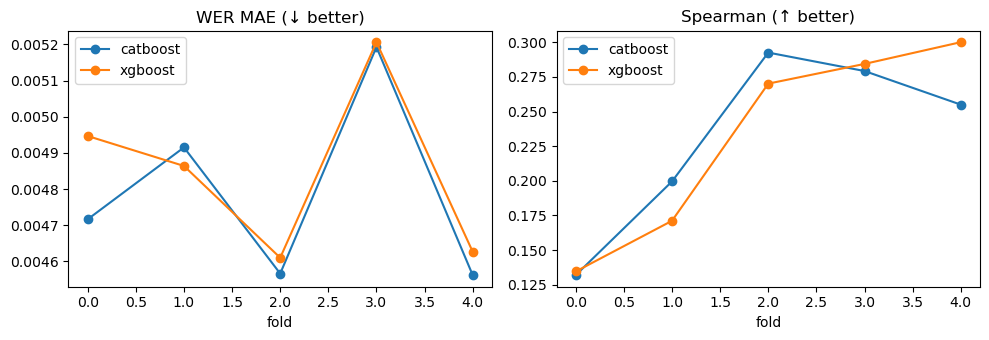

            mae             mae_bri  ...      rmse  spearman          
model  catboost   xgboost  catboost  ...   xgboost  catboost   xgboost
fold                                 ...                              
0      0.004716  0.004947  0.699489  ...  0.007458  0.131918  0.134533
1      0.004915  0.004864  0.741975  ...  0.007689  0.199550  0.171139
2      0.004566  0.004610  0.724697  ...  0.006522  0.292614  0.270192
3      0.005193  0.005206  0.797573  ...  0.008563  0.279292  0.284416
4  


mae             mae_bri  ...      rmse  spearman          
model  catboost   xgboost  catboost  ...   xgboost  catboost   xgboost
fold                                 ...                              
0      0.004716  0.004947  0.699489  ...  0.007458  0.131918  0.134533
1      0.004915  0.004864  0.741975  ...  0.007689  0.199550  0.171139
2      0.004566  0.004610  0.724697  ...  0.006522  0.292614  0.270192
3      0.005193  0.005206  0.797573  ...  0.008563  0.279292  0.284416
4      0.004562  0.004627  0.715170  ...  0.006671  0.255025  0.300124

[5 rows x 8 columns]

In [5]:
fold_detail = pd.concat([cv[m].scores for m in cv], ignore_index=True)
display(fold_detail.pivot_table(index="fold", columns="model", values=["mae", "rmse", "spearman", "mae_bri"]))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, metric, title in zip(axes, ["mae", "spearman"], ["WER MAE (↓ better)", "Spearman (↑ better)"]):
    for m, res in cv.items():
        ax.plot(res.scores["fold"], res.scores[metric], marker="o", label=m)
    ax.set_xlabel("fold")
    ax.set_title(title)
    ax.legend()
fig.tight_layout()
plt.show()

## 3. Holdout (winner) + BRI conversion

In [6]:
hold = holdout_eval(
    data,
    BEST,
    test_size=0.2,
    pca_dims=PCA_DIMS,
    iterations=ITERATIONS,
)
print(f"model={BEST}  n_train={hold['n_train']:,}  n_test={hold['n_test']:,}")
print("train brand baselines (median WER):", hold["baselines"])
print("holdout metrics:", hold["metrics"])

bri_true = wer_to_bri(hold["y_true"], hold["brands"], hold["baselines"])
bri_pred = hold["bri_pred"]
print(
    f"BRI holdout — median true={np.nanmedian(bri_true):.3f}  "
    f"median pred={np.nanmedian(bri_pred):.3f}  "
    f"share pred>1={float(np.mean(bri_pred > 1)):.1%}"
)

model=catboost  n_train=3,800  n_test=618
train brand baselines (median WER): {'adidas': 0.007130180140207649, 'nike': 0.00581508689346932}
holdout metrics: {'mae': 0.004993868273554502, 'rmse': 0.008424255131751207, 'spearman': 0.2889779764725098, 'mae_bri': 0.7616767949971271}
BRI holdout — median true=1.077  median pred=1.138  share pred>1=69.6%


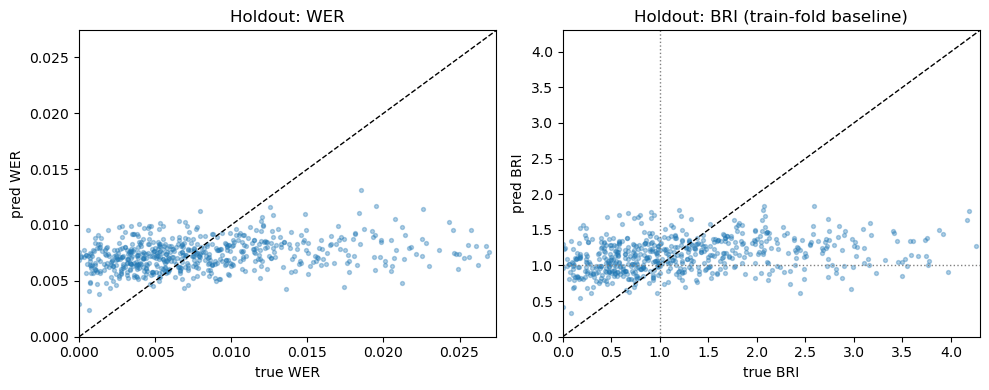

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(hold["y_true"], hold["y_pred"], s=8, alpha=0.35)
lim = np.nanpercentile(np.r_[hold["y_true"], hold["y_pred"]], 99)
axes[0].plot([0, lim], [0, lim], "k--", lw=1)
axes[0].set_xlim(0, lim)
axes[0].set_ylim(0, lim)
axes[0].set_xlabel("true WER")
axes[0].set_ylabel("pred WER")
axes[0].set_title("Holdout: WER")

axes[1].scatter(bri_true, bri_pred, s=8, alpha=0.35)
blim = np.nanpercentile(np.r_[bri_true, bri_pred], 99)
axes[1].plot([0, blim], [0, blim], "k--", lw=1)
axes[1].axhline(1, color="gray", ls=":", lw=1)
axes[1].axvline(1, color="gray", ls=":", lw=1)
axes[1].set_xlim(0, blim)
axes[1].set_ylim(0, blim)
axes[1].set_xlabel("true BRI")
axes[1].set_ylabel("pred BRI")
axes[1].set_title("Holdout: BRI (train-fold baseline)")
fig.tight_layout()
plt.show()

## 4. Feature importance (holdout winner)

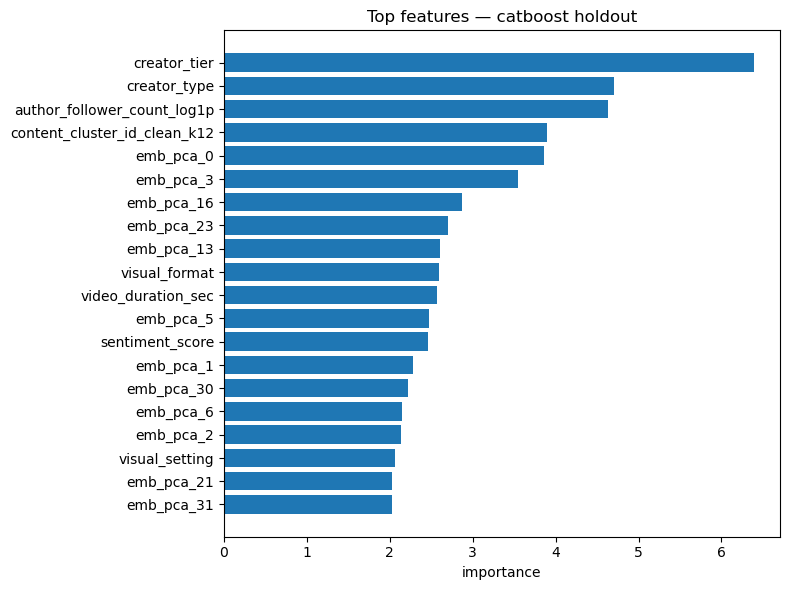

                         feature  importance
0                   creator_tier    6.387287
1                   creator_type    4.704332
2    author_follower_count_log1p    4.636056
3   content_cluster_id_clean_k12    3.892689
4                      emb_pca_0    3.863397
5                      emb_pca_3    3.550016
6                     emb_pca_16    2.867094
7                     emb_pca_23    2.705110
8                     emb_pca_13    2.606107
9                  visual_format    2.591368
10   

CV-mean importance (top 15):
                         feature  importance_mean
0    author_follower_count_log1p         4.782556
1                   creator_tier         4.179493
2                   creator_type         3.538112
3                      emb_pca_0         3.526390
4             video_duration_sec         3.476061
5                      emb_pca_3         3.026298
6                     emb_pca_18         2.832740
7                  visual_format         2.826004
8   content_cluster

,feature,importance
0,creator_tier,6.387287
1,creator_type,4.704332
2,author_follower_count_log1p,4.636056
3,content_cluster_id_clean_k12,3.892689
4,emb_pca_0,3.863397
5,emb_pca_3,3.550016
6,emb_pca_16,2.867094
7,emb_pca_23,2.705110
8,emb_pca_13,2.606107
9,visual_format,2.591368


,feature,importance_mean
0,author_follower_count_log1p,4.782556
1,creator_tier,4.179493
2,creator_type,3.538112
3,emb_pca_0,3.526390
4,video_duration_sec,3.476061
5,emb_pca_3,3.026298
6,emb_pca_18,2.832740
7,visual_format,2.826004
8,content_cluster_id_clean_k12,2.796819
9,emb_pca_13,2.443636


In [8]:
imp = hold["importances"].head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp["feature"], imp["importance"])
ax.set_title(f"Top features — {BEST} holdout")
ax.set_xlabel("importance")
fig.tight_layout()
plt.show()

display(hold["importances"].head(20))
if cv[BEST].importances is not None:
    print("\nCV-mean importance (top 15):")
    display(cv[BEST].importances.head(15))

## Takeaways

1. Models compete on **WER MAE** under author-grouped CV; winner retrained for grouped holdout.
2. **BRI** is a post-hoc conversion for within-brand ranking — not the training target.
3. Importances are descriptive (trees + PCA embeddings); not causal effects.
4. Next: Theme 1 brief (`04a`) synthesizes 02 crosstabs + 03 model signals.